Used PowerTransformer (Yeo-Johnson)


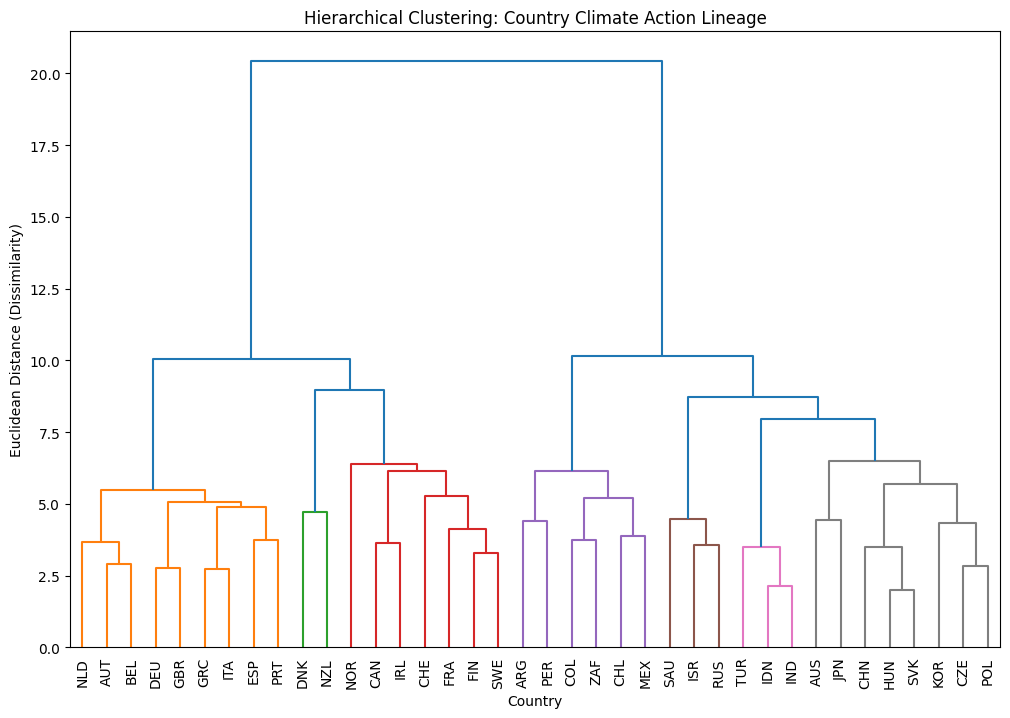

In [2]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import pandas as pd

import sys
import os

sys.path.append(os.path.abspath(os.path.join('../..', '..'))) 

from src.preprocessing import preprocess_dataset
from src.preprocessing import preprocess_dataset

# Get the  unscaled data
# Can specify which method to use in the preprocess_dataset function: 'standard' or 'power'
X_scaled = preprocess_dataset('../../../data/processed/cleaned_feature_matrix.csv',
                             '../../../data/processed/cleaned_and_scaled.csv',
                             method='power')

df_averaged = pd.read_csv('../../../data/processed/final_feature_matrix.csv')

# Generate the linkage matrix 
linked = linkage(X_scaled, method='ward')

# Plot the Dendrogram
plt.figure(figsize=(12, 8))
dendrogram(linked,
           labels=df_averaged['country_code'].values, # Use country codes as labels
           leaf_rotation=90,
           leaf_font_size=10,
           color_threshold=7) # Adjust this to cut at dif levels

plt.title('Hierarchical Clustering: Country Climate Action Lineage')
plt.xlabel('Country')
plt.ylabel('Euclidean Distance (Dissimilarity)')
plt.show()

cutting at about distance 8 seems to be the best option then there are 4 distinct groups...

In [4]:
from scipy.cluster.hierarchy import fcluster

# Cut at 4
k = 4
clusters = fcluster(linked, k, criterion='maxclust')

# Add to df and look at averages for each group
df_averaged['Hierarchical_Cluster'] = clusters

# Change to int for easier grouping
df_averaged['Hierarchical_Cluster'] = df_averaged['Hierarchical_Cluster'].astype(int)

# Now, look at the averages for each group
cluster_profile = df_averaged.groupby('Hierarchical_Cluster').mean(numeric_only=True)
print(cluster_profile)

                      nd_gain_score  coal_electricity_pct  \
Hierarchical_Cluster                                        
1                         64.497333             16.602967   
2                         70.748771              6.924408   
3                         50.543999             23.821971   
4                         58.303945             40.848309   

                      energy_use_per_capita  gdp_constant_usd  \
Hierarchical_Cluster                                            
1                               3127.449511      1.313591e+12   
2                               4468.335841      7.638861e+11   
3                               1528.796146      4.868765e+11   
4                               3353.698735      2.044453e+12   

                      gdp_per_capita_constant  renewable_electricity_pct  \
Hierarchical_Cluster                                                       
1                                35529.908623                  24.250194   
2             

In [6]:
# Print out the countries in each cluster
for cluster_num in range(1, k+1):
    countries_in_cluster = df_averaged[df_averaged['Hierarchical_Cluster'] == cluster_num]['country_code'].tolist()
    print(f"Cluster {cluster_num}: {countries_in_cluster}")

Cluster 1: ['AUT', 'BEL', 'DEU', 'ESP', 'GBR', 'GRC', 'ITA', 'NLD', 'PRT']
Cluster 2: ['CAN', 'CHE', 'DNK', 'FIN', 'FRA', 'IRL', 'NOR', 'NZL', 'SWE']
Cluster 3: ['ARG', 'CHL', 'COL', 'MEX', 'PER', 'ZAF']
Cluster 4: ['AUS', 'CHN', 'CZE', 'HUN', 'IDN', 'IND', 'ISR', 'JPN', 'KOR', 'POL', 'RUS', 'SAU', 'SVK', 'TUR']


# Super interesting

the smaller economies have the highest carbon tax mean


In [ ]:
import plotly.express as px

# Cluster labesl as strings
df_averaged['Cluster_Label'] = df_averaged['Hierarchical_Cluster'].astype(str)

# Create map
fig = px.choropleth(df_averaged, 
                    locations="country_code", 
                    color="Cluster_Label",    # Colors based archetypes
                    hover_name="Name",        # Shows the full country name on hover
                    title="Global Climate Action Archetypes (Hierarchical Clustering)",
                    color_discrete_map={      
                        '1': 'orange', 
                        '2': 'red', 
                        '3': 'green', 
                        '4': 'purple'
                    },
                    category_orders={"Cluster_Label": ["1", "2", "3", "4"]})

# Clean up
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()